Simulation to model muons emitted from a square source (x,y) with an angle taken from a cos^2 distribution. 

These trajectories were followed through a sphere beneath the source and the distance travelled within the sphere outputted.

say square is at z=0 position and the sphere centre is at (0,0,z=-d) position where d can be changed. 

square dimensions of 30x30cm and sphere has 30cm diameter

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Theta is the angle from the vertical.

Uniformly pick theta values from -pi/2 to pi/2

sub into PDF normalised from -pi/2 to pi/2: $f(\theta)= \frac{2}{\pi} cos^2 \theta$

pick another number, n, between 0 and 1,
keep theta if n $<cos^2\theta$

In [28]:
N=10000
square_length = 30
sphere_centre = np.array([0,0,-30])
sphere_radius = 15

x0 = np.zeros(N)
y0 = np.zeros(N)
z0 = np.zeros(N)
theta = np.zeros(N)
phi = np.zeros(N)
dx = np.zeros(N)
dy = np.zeros(N)
dz = np.zeros(N)
b = np.zeros(N)
chord = np.zeros(N)


for muon in range(N):
    x0[muon] = np.random.uniform(-square_length/2, square_length/2)
    y0[muon] = np.random.uniform(-square_length/2, square_length/2)
    z0[muon] = 0

    #angles
    accepted = False
    while not accepted:
        theta_trial = np.random.uniform(-np.pi/2, np.pi/2)
        n = np.random.uniform(0, 1)

        if n < (2/np.pi) * np.cos(theta_trial)**2:
            theta[muon] = theta_trial
            accepted = True

    phi[muon] = np.random.uniform(0,2*np.pi)

    #directions
    dx[muon] = np.sin(theta[muon])*np.cos(phi[muon])
    dy[muon] = np.sin(theta[muon])*np.sin(phi[muon])
    dz[muon] = -np.cos(theta[muon])


    #origins = (x0,y0,z0=0) = O
    #directions = (dx,dy,dz) = D
    #sphere centre = (0,0,-d) 
    O = np.array([x0[muon], y0[muon], z0[muon]])
    D = np.array([dx[muon], dy[muon], dz[muon]])
    O_C = O - sphere_centre

    b[muon] = np.linalg.norm(np.cross(O_C, D))

    chord[muon] = 0

    if b[muon] < sphere_radius:
        chord[muon] = 2*np.sqrt(sphere_radius**2 - b[muon]**2)
    else:
        chord[muon] = 0        
    


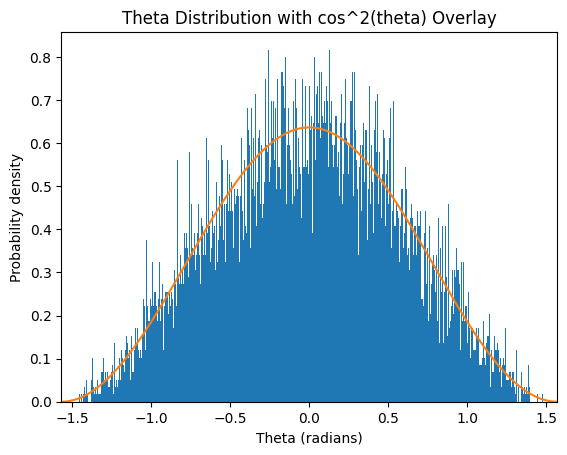

In [36]:
plt.figure()
plt.hist(theta, bins=500, density=True)

# Overlay cos^2(theta)
theta_vals = np.linspace(-np.pi/2, np.pi/2, 1000)
plt.plot(theta_vals, 2/np.pi * np.cos(theta_vals)**2)

plt.xlabel("Theta (radians)")
plt.ylabel("Probability density")
plt.title("Theta Distribution with cos^2(theta) Overlay")
plt.xlim(-np.pi/2, np.pi/2)
plt.show()

In [29]:
#print the simulated events into a table

df = pd.DataFrame({
    "x (cm)": x0,
    "y (cm)": y0,
    "z (cm)": z0,
    "theta (rad)": theta,
    "phi (rad)": phi,
    "chord length (cm)": chord,
    "closest approach to sphere centre": b
})

print(df.head())
print(np.sum(chord > 0))

     x (cm)     y (cm)  z (cm)  theta (rad)  phi (rad)  chord length (cm)  \
0 -3.976252 -10.911667     0.0     0.235122   1.710351          27.301921   
1 -7.372983  11.697737     0.0     0.131485   2.455481           0.000000   
2  7.618262  13.151210     0.0    -0.701097   4.463920           0.000000   
3 -1.415984   6.833499     0.0    -1.288462   0.744651           0.000000   
4  7.691261  -5.568145     0.0     1.004325   3.494217           0.000000   

   closest approach to sphere centre  
0                           6.217015  
1                          17.492641  
2                          30.804811  
3                          28.448652  
4                          23.814523  
4287


Now analyse the amount of energy deposited in the sphere by the muons.

Find this per muon and in total. 

This will be dependent on the gas in the sphere, Nitrogen, the pressure, say 1bar, and the chord length of the muon in the sphere. 



Mass stopping power for cosmic ray muons (MIPS):

$\frac{1}{\rho}\frac{dE}{dx}=2MeV/(g/cm^2)$

find density of Nitrogen:

$pV=nRT$

$n = \frac{m}{M_r}$

$pV = \frac{m}{M_r}RT$

$\rho = \frac{m}{V}$

so: $\rho = \frac{PM_r}{RT}$


In [30]:
pressure = 1 #in bars
room_temp = 293 #in Kelvin
gas_A = 14

dEdx_mass = 2 #MeV/gcm^2

density = (pressure*gas_A)/(8.31*room_temp)

dEdx = dEdx_mass * 1/density

print(dEdx)


347.83285714285716
